In [223]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, Dense
import nltk
from nltk.tokenize import word_tokenize
import numpy as np


import string

In [ ]:

nltk.download('stopwords')
# Загрузка ресурса punkt
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer

In [212]:
df = pd.read_csv("3rd_dataset.csv")
df.sample(10).values

array([['ДВА МЕТОДА АДАПТИВНОЙ МЕДИАННОЙ ФИЛЬТРАЦИИ ИМПУЛЬСНОГО ШУМА НА ИЗОБРАЖЕНИЯХ',
        'Автоматика. Вычислительная техника'],
       ['АНАЛИЗ ДЕЯТЕЛЬНОСТИ ЧЕЛЯБИНСКОЙ ТАМОЖНИ КАК АГЕНТА ВАЛЮТНОГО КОНТРОЛЯ',
        'Внешняя торговля'],
       ['АБЛЯЦИЯ МЕЛКИХ МЕТЕОРНЫХ ТЕЛ: СРАВНЕНИЕ МОДЕЛИ СПЛОШНОГО И ПОРИСТОГО ТЕЛА',
        'Автоматика. Вычислительная техника'],
       ['АЛГОРИТМ МАРКИРОВАНИЯ ТЕКСТОВЫХ ДОКУМЕНТОВ НА ОСНОВЕ ИЗМЕНЕНИЯ ИНТЕРВАЛОВ МЕЖДУ СЛОВАМИ, ОБЕСПЕЧИВАЮЩИЙ УСТОЙЧИВОСТЬ К ПРЕОБРАЗОВАНИЮ ФОРМАТА',
        'Автоматика. Вычислительная техника'],
       ['СИБИРСКИЙ РАДИОГЕЛИОГРАФ: ПЕРВЫЕ РЕЗУЛЬТАТЫ', 'Астрономия'],
       ['ПРИМЕНЕНИЕ МЕТОДОВ МАШИННОГО ОБУЧЕНИЯ ДЛЯ КЛАССИФИКАЦИИ РЕЗОНАНСНОГО ДВИЖЕНИЯ АСТЕРОИДОВ',
        'Астрономия'],
       ['ИСПОЛЬЗОВАНИЕ МЕТОДОВ МОЛЕКУЛЯРНОЙ ЦИТОГЕНЕТИКИ В ИССЛЕДОВАНИЯХ ОТДАЛЕННЫХ ГИБРИДОВ КАРТОФЕЛЯ',
        'Биотрехнология'],
       ['ФОРМЫ ГИБКОСТИ В ОПРЕДЕЛЕНИИ ТАМОЖЕННОЙ СТОИМОСТИ ТОВАРОВ ПО РЕЗЕРВНОМУ МЕТОДУ',
        '

<Axes: >

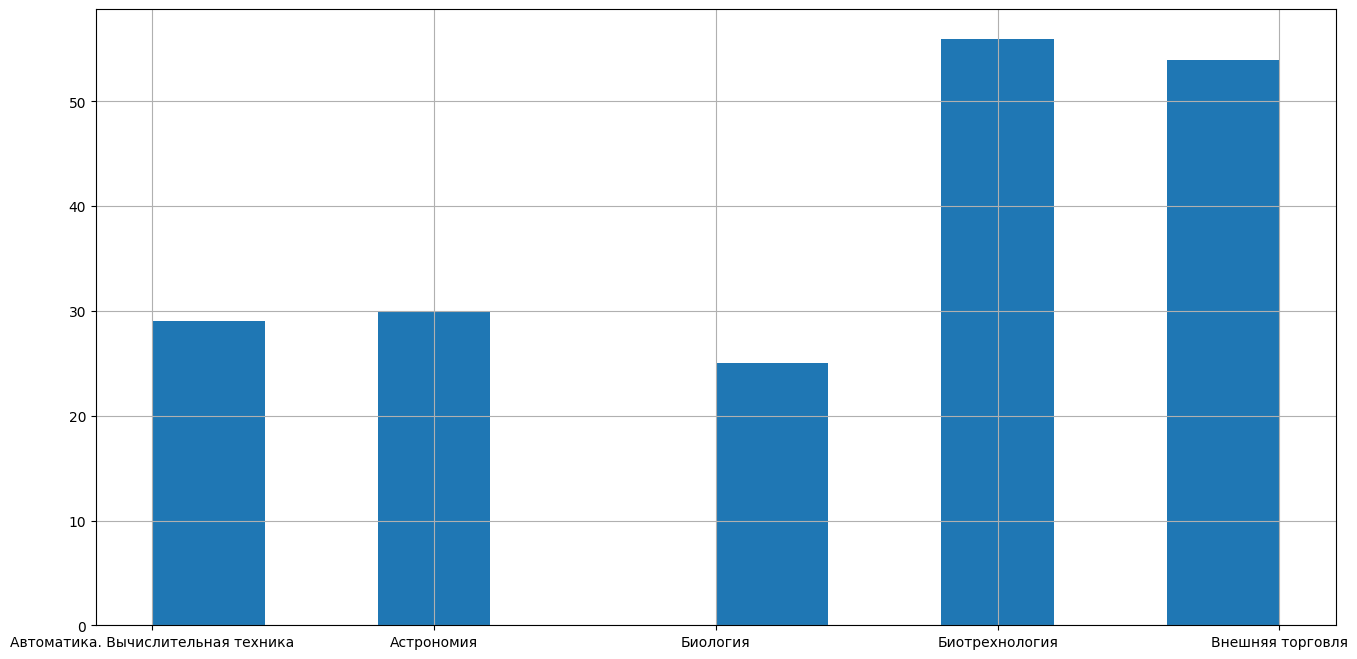

In [213]:
df['category'].hist(figsize=(16,8))

In [229]:
def preprocess(X):
    for i,text in enumerate(X):
        text = text.translate(str.maketrans('', '', string.punctuation)).lower()
        tokens = word_tokenize(text) #токенизация
        
        stop_words = set(stopwords.words('russian'))
        tokens = [word for word in tokens if word not in stop_words] #убираем стоп слова
        
        stemmer = SnowballStemmer("russian")
        tokens = [stemmer.stem(word) for word in tokens] # стемминг
        X[i] = tokens
    return X
preprocess(['СИСЬКИ И БАЗУКИ, ЧИПСЫ эпоха стемминг'])

[['сиськ', 'базук', 'чипс', 'эпох', 'стемминг']]

KeyError: 'accuracy'

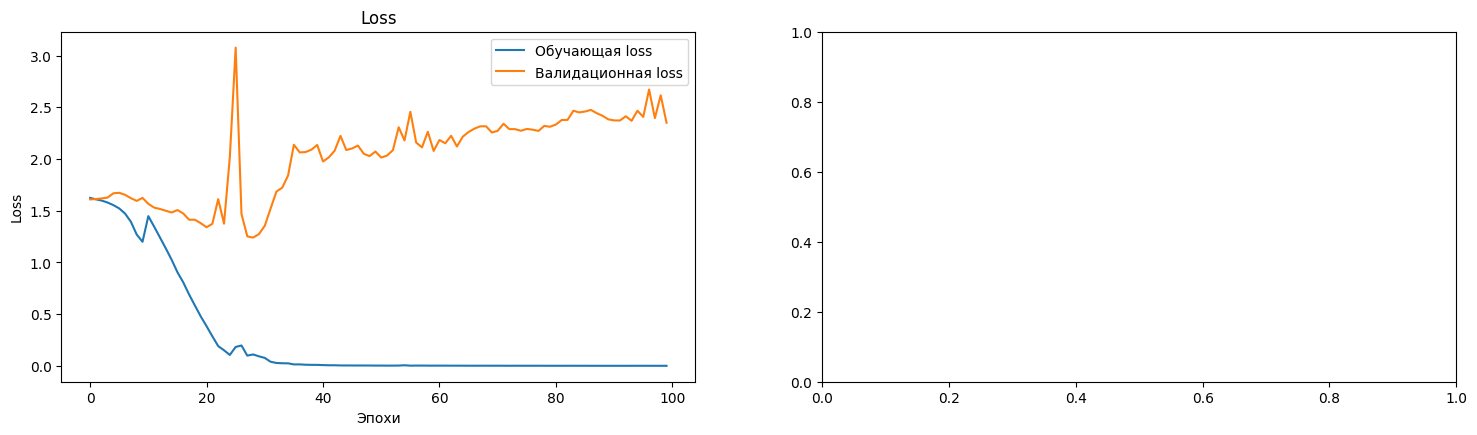

In [215]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1) 
plt.plot(history.history['loss'], label='Обучающая loss')
plt.plot(history.history['val_loss'], label='Валидационная loss')
plt.title('Loss')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.title('Accuracy')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.legend()

plt.ylim(0,1.01)

plt.tight_layout()  # автоматически подгоняет подграфики
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [210]:


text = "СИСЬКИ БАЗУКИ В ЧИПСЫ".lower()
tokens = word_tokenize(text)
stop_words = set(stopwords.words('russian'))
filtered_tokens = [word for word in tokens if word not in stop_words]

print(filtered_tokens)

['сиськи', 'базуки', 'чипсы']
